In [340]:
import numpy as np
import pandas as pd


In [341]:
df = pd.read_csv('spam.csv', encoding='latin1')

In [342]:
df.sample (5)

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
41,ham,"Did I forget to tell you ? I want you , I need...",NaN,NaN,NaN
179,ham,Hi! You just spoke to MANEESHA V. We'd like to...,NaN,NaN,NaN
4056,ham,Noice. Text me when you're here,NaN,NaN,NaN
4434,spam,Don't b floppy... b snappy & happy! Only gay c...,NaN,NaN,NaN
2916,ham,Yes. that will be fine. Love you. Be safe.,NaN,NaN,NaN


In [343]:
df.shape

(5572, 5)

In [344]:
# 1.data cleaning
# 2.eda
#3.text preprocessing
#4.model building
#5. evalution
#6. improvement
#7.website
#8.deploy

**## 1. DATA CLEANING**

In [345]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [346]:
# drop last 3 columns
df.drop(columns=['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], inplace=True)

In [347]:
df.sample(5)

,v1,v2
1458,ham,"Fighting with the world is easy, u either win ..."
5562,ham,Ok lor... Sony ericsson salesman... I ask shuh...
2532,ham,Yup ok...
1273,spam,network operator. The service is free. For T &...
4582,spam,For ur chance to win a å£250 wkly shopping spr...


In [348]:
# renaming the columns
df.rename(columns={'v1': 'target', 'v2': 'text'}, inplace=True)
df.sample(5)

,target,text
2387,ham,Also where's the piece
4790,ham,Send me your resume:-)
5432,ham,Thanx a lot 4 ur help!
1760,ham,Nt yet chikku..simple habba..hw abt u?
2753,ham,"Derp. Which is worse, a dude who always wants ..."


In [349]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()


In [350]:
df['target'] = encoder.fit_transform(df['target'])

In [351]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [352]:
# check missing values
df.isnull().sum()

,0
target,0
text,0


In [353]:
# Check for duplicate values
df.duplicated().sum()

np.int64(403)

In [354]:
# remove dulicate values
df = df.drop_duplicates(keep='first')

In [355]:
df.duplicated().sum()

np.int64(0)

In [356]:
df.shape

(5169, 2)

**## 2.EDA(Exploratory Data Analysis)**

In [357]:
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [358]:
df.value_counts()

target  text                                                                                                                                        
1       we tried to contact you re your response to our offer of a new nokia fone and camcorder hit reply or call 08000930705 for delivery              1
        network operator. The service is free. For T & C's visit 80488.biz                                                                              1
        money!!! you r a lucky winner ! 2 claim your prize text money 2 88600 over å£1million to give away ! ppt150x3+normal text rate box403 w1t1jy    1
        lyricalladie(21/F) is inviting you to be her friend. Reply YES-910 or NO-910. See her: www.SMS.ac/u/hmmross STOP? Send STOP FRND to 62468       1
        it to 80488. Your 500 free text messages are valid until 31 December 2005.                                                                      1
                                                                                                                                                       ..
0        gonna let me know cos comes bak from holiday that day.  is coming. Don't4get2text me  number.                                                  1
         came to look at the flat, seems ok, in his 50s? * Is away alot wiv work. Got woman coming at 6.30 too.                                         1
         and  picking them up from various points                                                                                                       1
         &lt;DECIMAL&gt; m but its not a common car here so its better to buy from china or asia. Or if i find it less expensive. I.ll holla            1
         &lt;#&gt;  mins but i had to stop somewhere first.                                                                                             1
Name: count, Length: 5169, dtype: int64

In [359]:
df['target'].value_counts()


,count
target,
0,4516
1,653


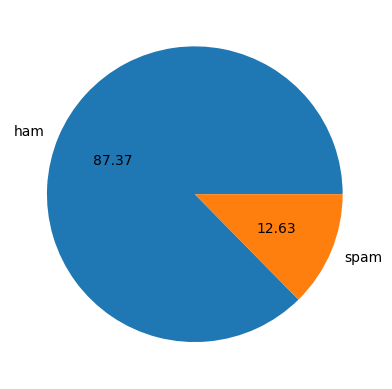

In [360]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels = ['ham', 'spam'],autopct="%0.2f")
plt.show()

In [361]:
# DATA IS IMBALANCED

In [362]:
import nltk

In [363]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [364]:
df['num_characters'] = df['text'].apply(len)

In [365]:
df.head()

,target,text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [366]:
nltk.download('punkt_tab')
df['num_words'] = df['text'].apply(lambda x:len(nltk.word_tokenize(x)))

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [367]:
df.head()

,target,text,num_characters,num_words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [368]:
df['num_sentences'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))

In [369]:
df.head()

,target,text,num_characters,num_words,num_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [370]:
df[df['target'] == 0] [['num_characters','num_words','num_sentences']].describe()


,num_characters,num_words,num_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [371]:
# spam
df[df['target'] == 1] [['num_characters','num_words','num_sentences']].describe()

,num_characters,num_words,num_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [372]:
import seaborn as sns

<Axes: xlabel='num_characters', ylabel='Count'>

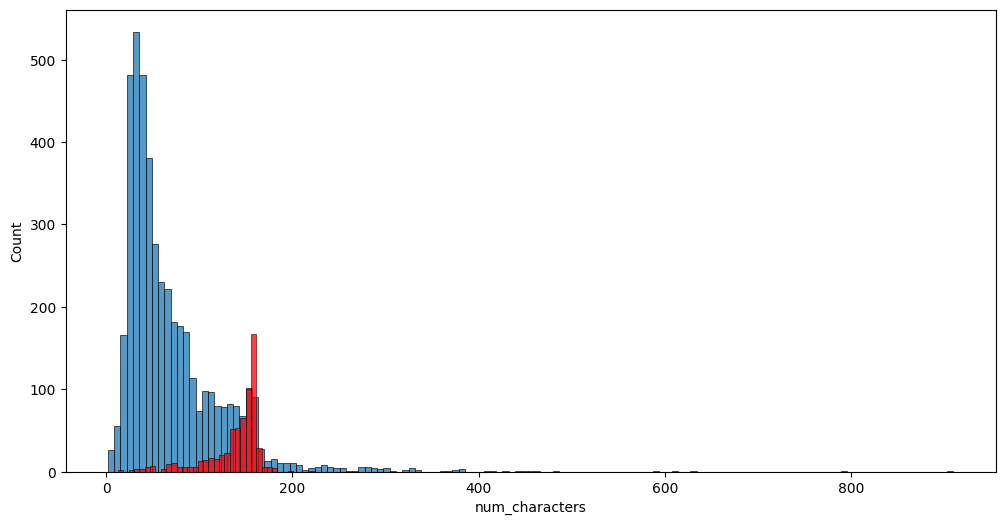

In [373]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0 ] ['num_characters'])
sns.histplot(df[df['target'] == 1 ] ['num_characters'],color = 'red')

<Axes: xlabel='num_words', ylabel='Count'>

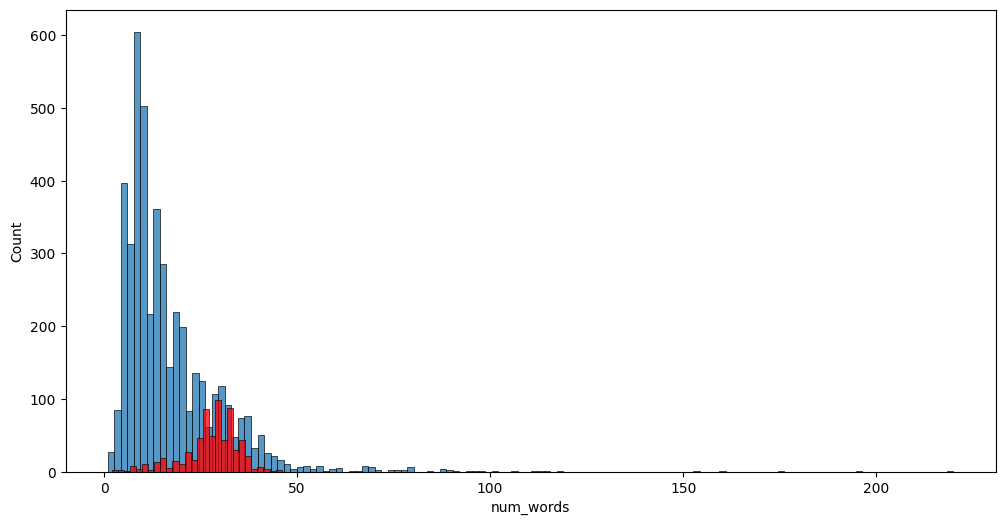

In [374]:
plt.figure(figsize=(12,6))
sns.histplot(df[df['target'] == 0 ] ['num_words'])
sns.histplot(df[df['target'] == 1 ] ['num_words'],color = 'red')

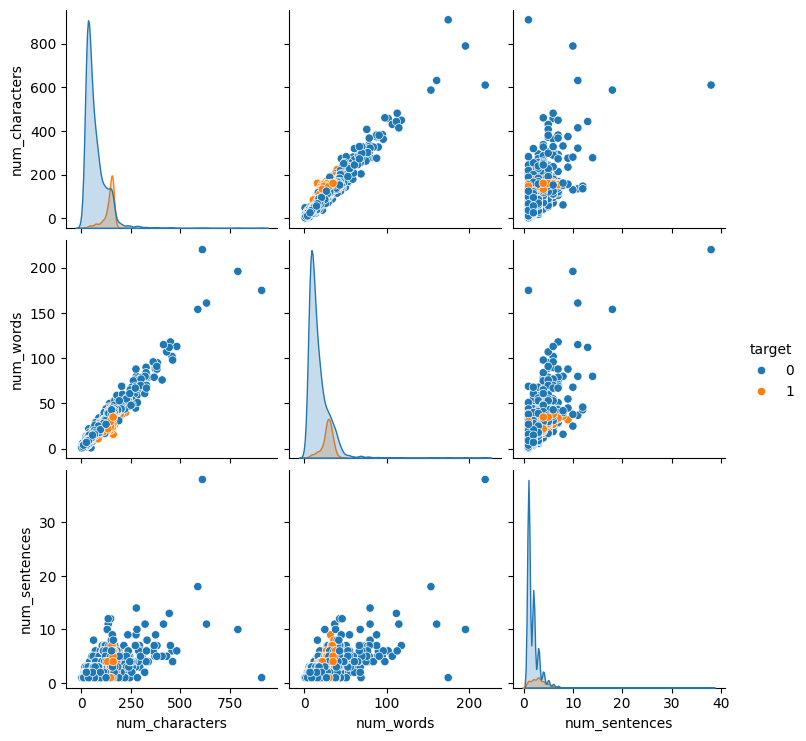

In [375]:
sns.pairplot(df,hue = 'target')

<Axes: >

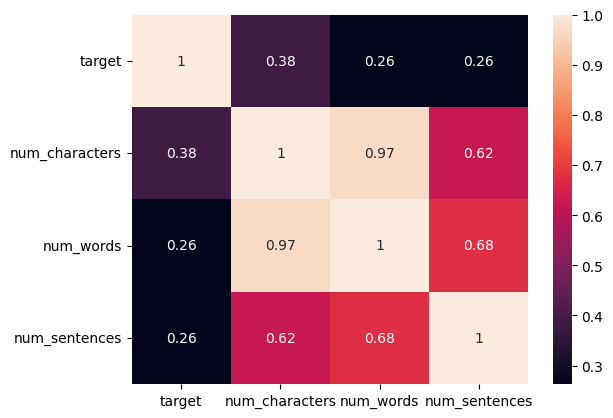

In [376]:
sns.heatmap(df.drop('text',axis=1).corr(),annot=True)

**Data Preprocessing**


*   Lower case
*   Tokenization
*   Removing Special Character
*   Removing stop word and punctuation
*   Stemming








In [377]:
def transform_text (text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  ps = PorterStemmer()
  for i in text :
    y.append(ps.stem(i))

  return " ".join(y)

In [378]:
import string
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [379]:
import nltk
import string
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

# Ensure stopwords are downloaded if not already
nltk.download('stopwords', quiet=True)

def transform_text (text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  ps = PorterStemmer()
  for i in text :
    y.append(ps.stem(i))

  return " ".join(y)

df['transformed_text'] = df['text'].apply(transform_text)

In [380]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [381]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [382]:
def transform_text (text):
  text = text.lower()
  text = nltk.word_tokenize(text)

  y = []
  for i in text:
    if i.isalnum():
      y.append(i)

  text = y[:]
  y.clear()

  for i in text:
    if i not in stopwords.words('english') and i not in string.punctuation:
      y.append(i)

  text = y[:]
  y.clear()

  ps = PorterStemmer()
  for i in text :
    y.append(ps.stem(i))

  return " ".join(y)

In [383]:
transform_text ('I loved the yt lectures on mechine learning. How about you? ')

'love yt lectur mechin learn'

In [384]:
print(transform_text(df['text'][2000]))

b go 2 sch mon si need 2 take smth


In [385]:
print(transform_text(df['text'][2000]))

b go 2 sch mon si need 2 take smth


In [386]:
df['text'][10]

"I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today."

In [387]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
ps.stem('loved')


'love'

In [388]:
df['text'].apply(transform_text)

,text
0,go jurong point crazi avail bugi n great world...
1,ok lar joke wif u oni
2,free entri 2 wkli comp win fa cup final tkt 21...
3,u dun say earli hor u c alreadi say
4,nah think goe usf live around though
...,...
5567,2nd time tri 2 contact u pound prize 2 claim e...
5568,b go esplanad fr home
5569,piti mood suggest
5570,guy bitch act like interest buy someth els nex...


In [389]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [390]:
from wordcloud import WordCloud
wc = WordCloud(width=500,height=500,min_font_size=10,background_color='white')

In [391]:
spam_wc =wc.generate(df[df['target'] == 1]['transformed_text'].str.cat(sep =" "))

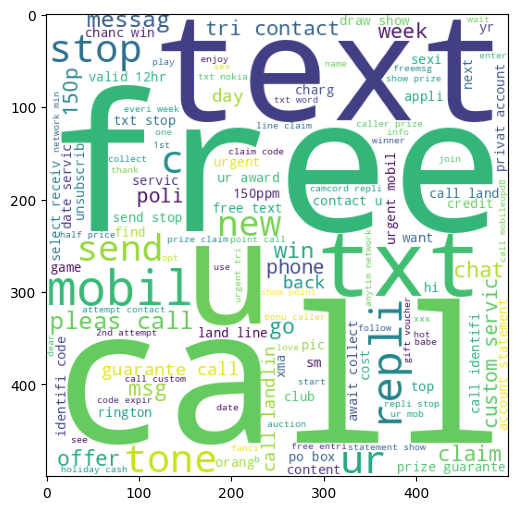

In [392]:
plt.figure(figsize=(15,6))
plt.imshow( spam_wc)

In [393]:
ham_wc =wc.generate(df[df['target'] == 0]['transformed_text'].str.cat(sep =" "))

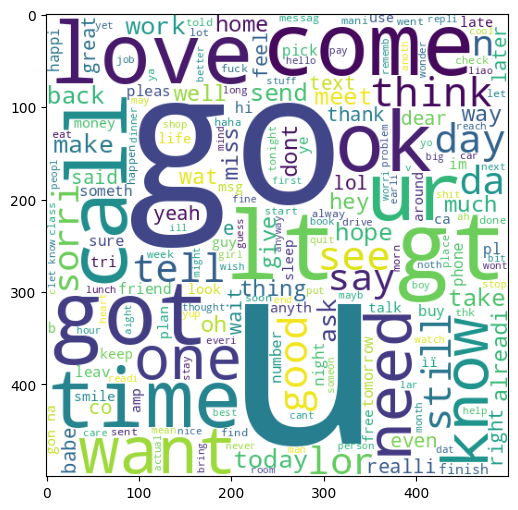

In [394]:
plt.figure(figsize=(15,6))
plt.imshow( ham_wc)

In [395]:
df.head()

,target,text,num_characters,num_words,num_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


In [396]:
spam_corpus = []
for msg in df[df['target'] == 1]['transformed_text'].tolist():
      for  word in msg.split():
              spam_corpus.append(word)

In [397]:
len(spam_corpus)

9939

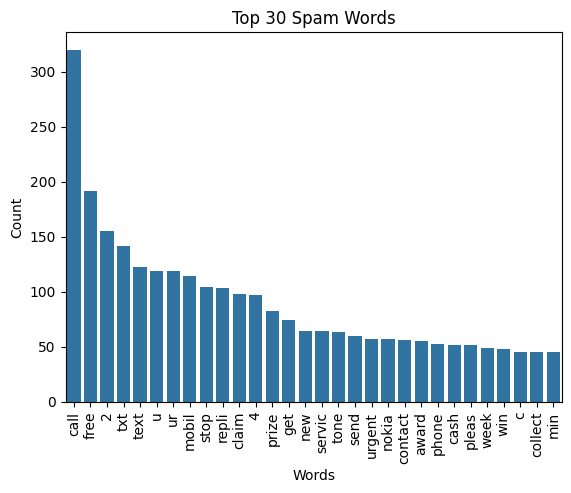

In [398]:
from collections import Counter
spam_common_words = pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=spam_common_words[0], y=spam_common_words[1])
plt.xticks(rotation=90)
plt.xlabel('Words')
plt.ylabel('Count')
plt.title('Top 30 Spam Words')
plt.show()

In [399]:
ham_corpus = []
for msg in df[df['target'] == 0]['transformed_text'].tolist():
      for  word in msg.split():
              ham_corpus.append(word)

In [400]:
len(ham_corpus)

35404

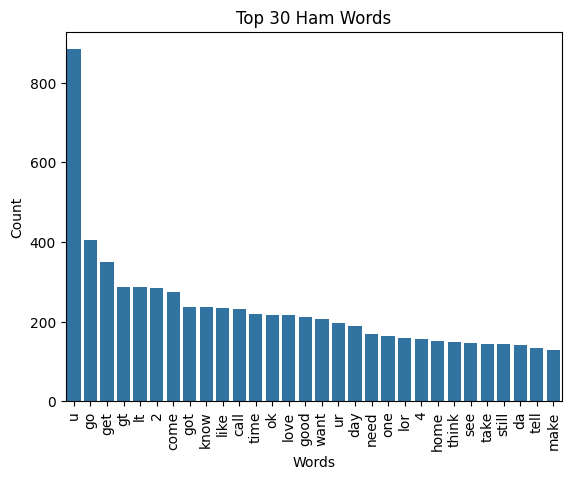

In [401]:
from collections import Counter
ham_common_words = pd.DataFrame(Counter(ham_corpus).most_common(30))
sns.barplot(x=ham_common_words[0], y=ham_common_words[1])
plt.xticks(rotation=90)
plt.xlabel('Words')
plt.ylabel('Count')
plt.title('Top 30 Ham Words')
plt.show()

**4. Model Building**

In [402]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
cv = CountVectorizer()
tfidf = TfidfVectorizer(max_features=3000)

In [403]:
x = cv.fit_transform(df['transformed_text']).toarray()

In [404]:
x.shape

(5169, 6708)

In [405]:
y = df['target'].values

In [406]:
from sklearn.model_selection import train_test_split

In [407]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, random_state=2)

In [408]:
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score



In [409]:
gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

In [410]:
gnb.fit(x_train , y_train)
y_pred1 = gnb.predict(x_test)
print (accuracy_score(y_test,y_pred1))
print (confusion_matrix(y_test,y_pred1))
print (precision_score(y_test,y_pred1))

0.8800773694390716
[[792 104]
 [ 20 118]]
0.5315315315315315


In [411]:
mnb.fit(x_train , y_train)
y_pred2 = mnb.predict(x_test)
print (accuracy_score(y_test,y_pred2))
print (confusion_matrix(y_test,y_pred2))
print (precision_score(y_test,y_pred2))

0.9642166344294004
[[871  25]
 [ 12 126]]
0.8344370860927153


In [412]:
bnb.fit(x_train , y_train)
y_pred3 = bnb.predict(x_test)
print (accuracy_score(y_test,y_pred3))
print (confusion_matrix(y_test,y_pred3))
print (precision_score(y_test,y_pred3))

0.9700193423597679
[[893   3]
 [ 28 110]]
0.9734513274336283


# tfidf --> MNB

In [413]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [414]:
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
dtc = DecisionTreeClassifier(max_depth=5)
lrc = LogisticRegression(solver='liblinear', penalty='l1')
rfc = RandomForestClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
bc = BaggingClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)

clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB': mnb,
    'DT': dtc,
    'LR': lrc,
    'RF': rfc,
    'AdaBoost': abc,
    'BgC': bc,
    'ETC': etc,
    'GBDT':gbdt,
    'xgb':xgb
}

In [415]:
def train_classifier(clf,X_train,y_train,X_test,y_test):
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)

    return accuracy,precision

In [416]:
train_classifier(svc,x_train,y_train,x_test,y_test)

(0.9264990328820116, 0.7421875)

In [ ]:
accuracy_scores = []
precision_scores = []

for name,clf in clfs.items():

    current_accuracy,current_precision = train_classifier(clf, x_train,y_train,x_test,y_test)

    print("For ",name)
    print("Accuracy - ",current_accuracy)
    print("Precision - ",current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)

For  SVC
Accuracy -  0.9264990328820116
Precision -  0.7421875
For  KN
Accuracy -  0.90715667311412
Precision -  1.0
For  NB
Accuracy -  0.9642166344294004
Precision -  0.8344370860927153
For  DT
Accuracy -  0.925531914893617
Precision -  0.9420289855072463
For  LR
Accuracy -  0.9709864603481625
Precision -  0.9736842105263158
For  RF
Accuracy -  0.971953578336557
Precision -  1.0
For  AdaBoost
Accuracy -  0.9197292069632496
Precision -  0.9365079365079365
For  BgC
Accuracy -  0.9622823984526112
Precision -  0.9159663865546218
For  ETC
Accuracy -  0.97678916827853
Precision -  0.9913793103448276
For  GBDT
Accuracy -  0.9439071566731141
Precision -  0.9444444444444444


In [ ]:
performance_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy':accuracy_scores,'Precision':precision_scores}).sort_values('Precision',ascending=False)

In [ ]:
performance_df

In [ ]:
performance_df1 = pd.melt(performance_df, id_vars = "Algorithm")

In [ ]:
performance_df1

In [ ]:
sns.catplot(x = 'Algorithm', y='value',
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

# model improve
# 1. Change the max_features parameter of TfIdf

In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_max_ft_3000':accuracy_scores,'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_scaling':accuracy_scores,'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [ ]:
new_df = performance_df.merge(temp_df,on='Algorithm')

In [ ]:
new_df_scaled = new_df.merge(temp_df,on='Algorithm')

In [ ]:
temp_df = pd.DataFrame({'Algorithm':clfs.keys(),'Accuracy_num_chars':accuracy_scores,'Precision_num_chars':precision_scores}).sort_values('Precision_num_chars',ascending=False)

In [ ]:
new_df_scaled.merge(temp_df,on='Algorithm')

In [ ]:
# Voting Classifier
svc = SVC(kernel='sigmoid', gamma=1.0,probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [ ]:
voting = VotingClassifier(estimators=[('svm', svc), ('nb', mnb), ('et', etc)],voting='soft')

In [339]:
voting.fit(x_train,y_train)

VotingClassifier(estimators=[('svm',
                              SVC(gamma=1.0, kernel='sigmoid',
                                  probability=True)),
                             ('nb', MultinomialNB()),
                             ('et',
                              ExtraTreesClassifier(n_estimators=50,
                                                   random_state=2))],
                 voting='soft')

In [ ]:
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

In [ ]:
# Applying stacking
estimators=[('svm', svc), ('nb', mnb), ('et', etc)]
final_estimator=RandomForestClassifier()

In [ ]:
from sklearn.ensemble import StackingClassifier

In [ ]:
clf = StackingClassifier(estimators=estimators, final_estimator=final_estimator)

In [ ]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

In [ ]:
import pickle
pickle.dump(tfidf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))

In [ ]:
y_pred = voting.predict(x_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))